# 🧠🤖 O Algoritmo de Descida do Gradiente

Este notebook tem como objetivo introduzir o algoritmo de **descida do gradiente**, o método utilizado para treinamento de redes neurais modernas.

Nesta aula, você vai:
- Entender o que são problemas de otimização
- Conhecer diferentes tipos de problemas (lineares, inteiros, convexos, não convexos)
- Estudar em quais casos faz sentido usar algoritmos baseados em gradiente
- Aprender o algoritmo de descida do gradiente
- Aplicar e visualizar o algoritmo em funções simples


## Problemas de Otimização


Problemas de otimização são aqueles que podem ser escritos na forma: 

$$
x^* = \argmin_{x \in S} f(x) \text{, sujeito às restrições R}
$$

ou

$$
x^* = \argmax_{x \in S} f(x) \text{, sujeito às restrições R}
$$

onde:

- $f(x)$ é a **função objetivo** a ser minimizada ou maximizada.
- $S$ é o **domínio** das soluções, isto é, os conjuntos de valores válidos como soluções.
- $x$ é uma solução possível.
- $x^*$ é a solução ótima.
- $R$ é uma coleção de restrições que precisam ser obedecidas. A coleção pode ser vazia.


## Fundamentação Teórica do Algoritmo de Descida do Gradiente (*Gradient Descent*)




### Derivadas Direcionais

As derivadas parciais podem ser vistas como a derivada na direção de um dos *vetores da base padrão*, isto é, $\frac{\partial f(x, y)}{\partial x}$ é a derivada na direção $x$ ou na direção $(1, 0)$ e $\frac{\partial f(x, y)}{\partial y}$ é a derivada na direção $y$ ou $(0, 1)$. Podemos generalizar esta noção em um conceito chamado de **derivada direcional**. 

Dado um vetor $\mathbf{d}$, a **derivada direcional** é o tamanho da projeção do gradiente na direção de $\mathbf{d}$. Este valor pode ser obtido fazendo o produto interno do gradiente com $\mathbf{d}$:

$$
f'_\mathbf{d}(\mathbf{x}) = \mathbf{d} \cdot \nabla_{\mathbf{x}} f(\mathbf{x})
$$




### O Gradiente aponta para a Direção de Máximo Crescimento (*Steepest Ascent*)


Vamos definir a direção de máximo crescimento como sendo a direção do vetor unitário $\mathbf{d^{*}}$ para a qual a derivada direcional é máxima: 

$$
\mathbf{d^*} = \argmax_{\mathbf{d}:||\mathbf{d}||=1} f'_d(\mathbf{x})
$$



Aplicando a definição da derivada direcional e reescrevendo o produto interno em função da magnitude e ângulo entre os vetores: 

$$
\mathbf{d^*} = \argmax_{\mathbf{d}:||\mathbf{d}||=1} ||\mathbf{d}|| \  ||\nabla_{\mathbf{x}} f(\mathbf{x})|| \cos(\theta)
$$

onde $\theta$ é o ângulo entre $\mathbf{d}$ e $\nabla_{\mathbf{x}} f(\mathbf{x})$.


Como $||d|| = 1$ por definição: 

$$
\mathbf{d^*} = \argmax_{\mathbf{d}:||\mathbf{d}||=1} ||\nabla_{\mathbf{x}} f(\mathbf{x})|| \cos(\theta)
$$

O valor será máximo quando $\theta = 0$ e isso acontece quando $\mathbf{d}$ está na mesma direção do gradiente, portanto:

$$
\mathbf{d^*} = \nabla_{\mathbf{x}} f(\mathbf{x})
$$

Concluímos assim que **a direção do gradiente é a direção de máximo crescimento da função**. 

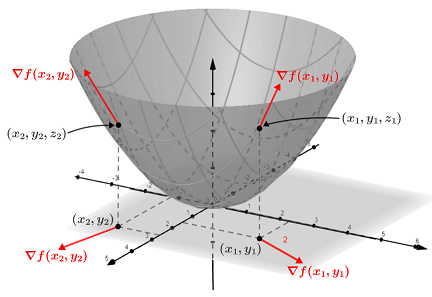




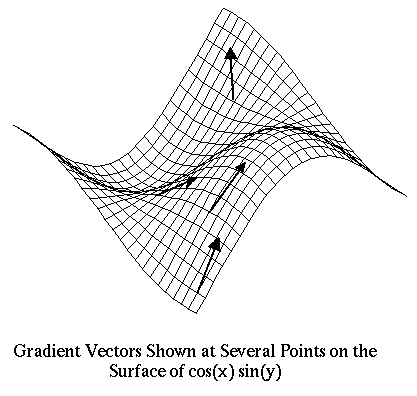

## O Algoritmo de Descida do Gradiente (Gradient Descent)


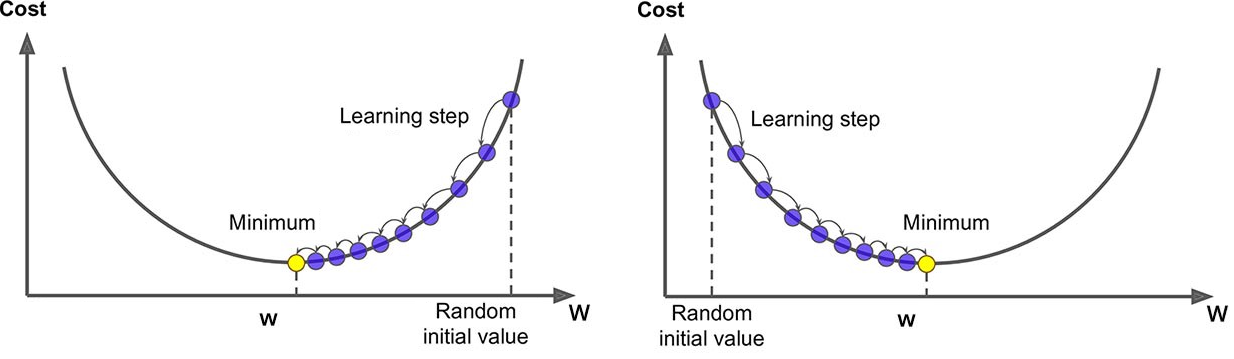


Dada uma função objetivo diferenciável, o **algoritmo de descida do gradiente** (*gradient descent*) se propõe a, partindo de um **ponto inicial (possivelmente aleatório)**, caminhar na direção **contrária à do vetor gradiente**, isto é, na direção de decrescimento da função. 

Formalmente, o problema de otimização é encontrar um mínimo $\mathbf{x^*}$ de uma função objetivo $f$ diferenciável: 

$$
\mathbf{x^*} = \argmin_\mathbf{x} f(\mathbf{x})
$$

Partindo de uma posição aleatória inicial $\mathbf{x_0}$, utilizamos iterativamente a seguinte regra de atualização:

$$
\mathbf{x_{t+1}} = \mathbf{x_t} - \alpha \nabla f
$$

onde $\alpha$ é um **hiperparâmetro** chamado de **taxa de aprendizado** que controla o tamanho dos passos. 

Dado um número suficiente grande de passos e uma taxa de aprendizado suficientemente pequena, é possível provar que **o algoritmo de descida do gradiente sempre converge para um mínimo local**.


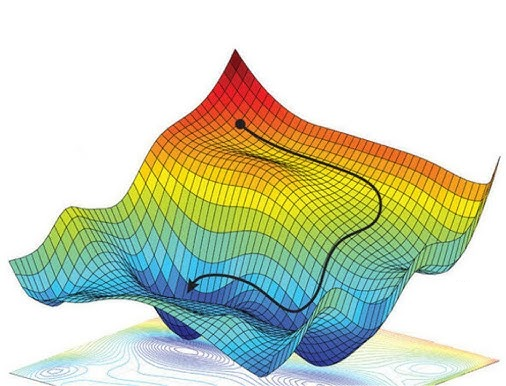

### Implementação

In [1]:
def gradient_descent(gradient_fn, initial_val, learning_rate, n_iter):
    w = initial_val

    for _ in range(n_iter):
        w = w - learning_rate * gradient_fn(w)

    return w


### Em que problemas de otimização podemos utilizar algoritmos baseados em gradiente?

Algoritmos baseados em gradiente são adequados quando:
- A função objetivo é **diferenciável** 
- Estamos lidando com **variáveis contínuas**
- Podemos calcular ou estimar o gradiente da função

**Eles não são adequados para:**
- Funções com variáveis inteiras
- Funções com muitas descontinuidades

### Máximos Globais vs. Locais


Como indicado na Figura abaixo, funções podem possuir mínimos e máximos globais e locais. 

Nem todo algoritmo de otimização é capaz de encontrar ótimos globais. O algoritmo de descida do gradiente, por exemplo, só possui garantias de convergência para ótimos locais. Felizmente, em muitos problemas de interesse, ótimos locais representam soluções boas o suficiente.


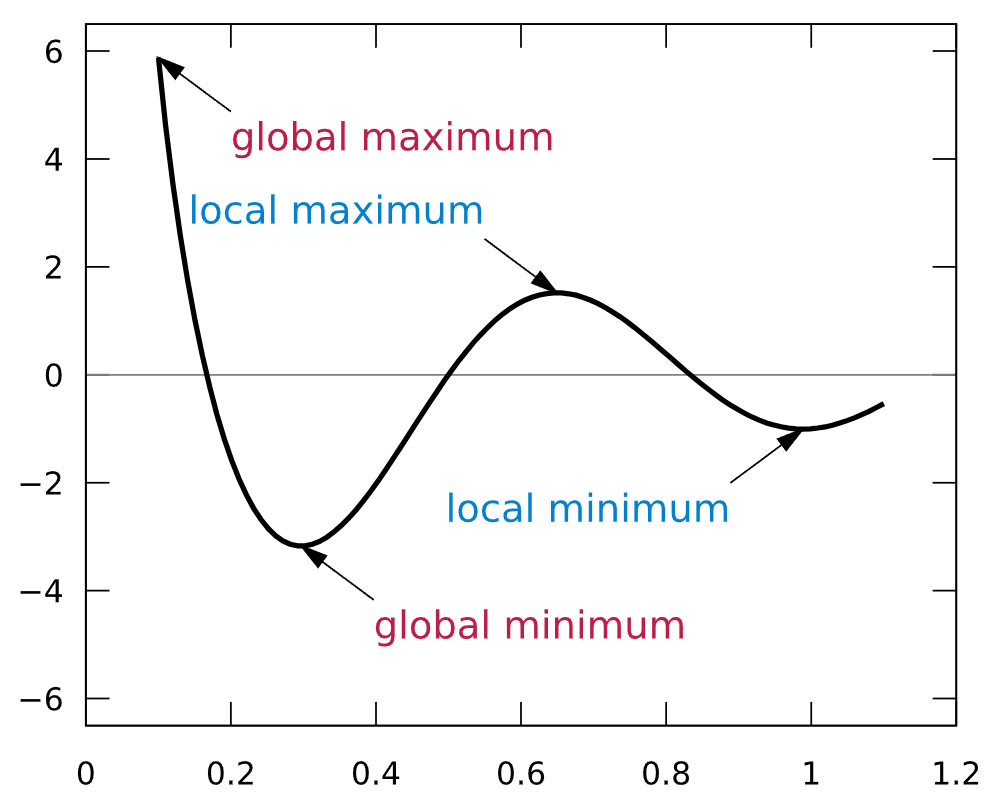

## Exemplos 

Nos exemplos abaixo, vamos usar uma variação do algoritmo em que o histórico de variáveis é armazenado. 

⚠️ **Cuidado**: Salvar o valor das variáveis pode consumir muita memória se o número de variáveis é grande!

In [2]:

def gradient_descent(gradient_fn, initial_val, learning_rate, n_iter):
    w = initial_val
    history = [w]

    for _ in range(n_iter):
        w = w - learning_rate * gradient_fn(w)
        history.append(w)

    return history

In [54]:
import numpy as np
import matplotlib.pyplot as plt


def plot2d(history, objective_fn, show_x_path=False):
  xl = -max(abs(min(history)), abs(max(history)))
  xr = max(abs(min(history)), abs(max(history)))
  diff = abs(xr - xl) * 0.1
  xl -= diff
  xr += diff
  x_vals = np.linspace(xl, xr, 100)
  plt.plot(x_vals, objective_fn(x_vals), label='f(x) = x^2')
  plt.plot(history, [objective_fn(x) for x in history], 'o-', label='Gradient Descent')
  if show_x_path:
    plt.plot(history, [0 for x in history], 'o-', label=None)
  plt.xlabel('x')
  plt.ylabel('f(x)')
  plt.title('Descida do Gradiente em f(x) = x^2')
  plt.legend()
  plt.grid(True)
  plt.show()

### Exemplo: Função $x^2$

min_x:  4.547473508864641e-12 f(min_x):  2.0679515313825692e-23


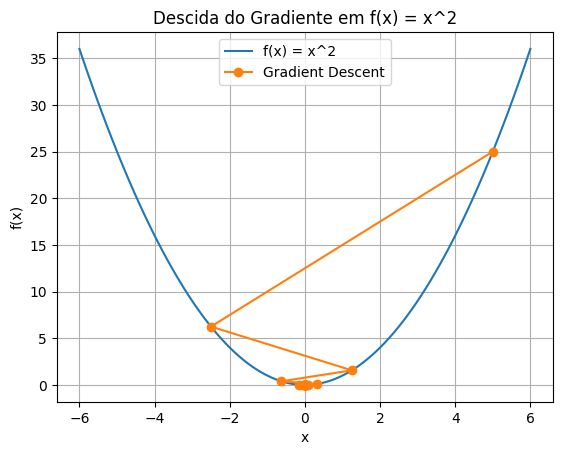

In [63]:
import numpy as np

def objective_fn(x):
    return x ** 2

def gradient_fn(x):
    return 2 * x

history = gradient_descent(gradient_fn, initial_val=5.0, learning_rate=0.75, n_iter=40)
print("min_x: ", history[-1], "f(min_x): ", objective_fn(history[-1]))
plot2d(history, objective_fn, show_x_path=False)

### Exemplo: $x^3$

min_x:  0.171633702666966 f(min_x):  0.005056007563598959


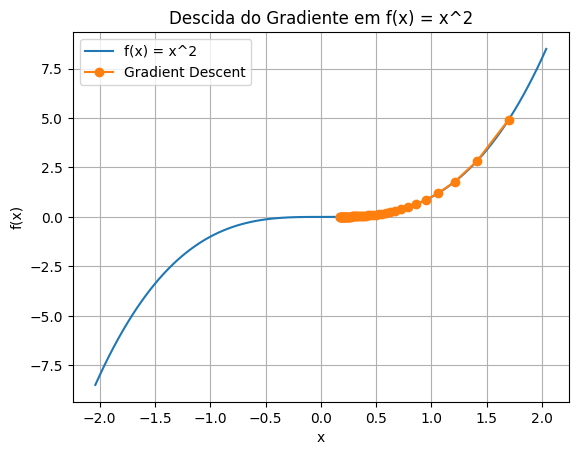

In [56]:
import numpy as np

def objective_fn(x):
    return x ** 3

def gradient_fn(x):
    return 2 * x ** 2

history = gradient_descent(gradient_fn, initial_val=1.7, learning_rate=0.05, n_iter=50)
print("min_x: ", history[-1], "f(min_x): ", objective_fn(history[-1]))
plot2d(history, objective_fn)

### Exemplo: $4x^4 - 2x^3 - 12 x^2$

min_x:  1.42645368561815 f(min_x):  -13.661094353111437


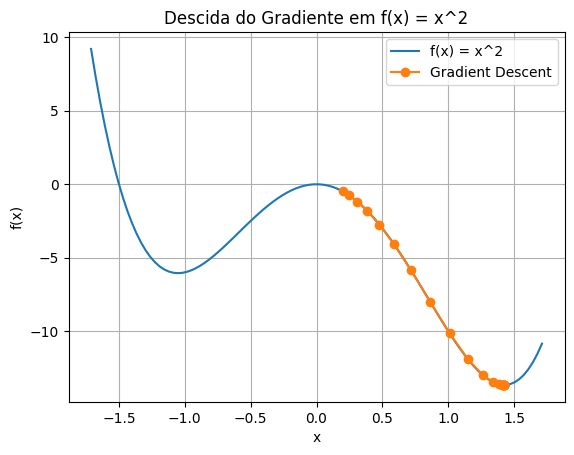

In [57]:
import numpy as np

def objective_fn(x):
    return 4 * x ** 4 - 2 * x ** 3 - 12 * x ** 2

def gradient_fn(x):
    return 16 * x ** 3 - 6 * x ** 2 - 24 * x

history = gradient_descent(gradient_fn, initial_val=0.2, learning_rate=0.01, n_iter=20)
print("min_x: ", history[-1], "f(min_x): ", objective_fn(history[-1]))
plot2d(history, objective_fn)

### Exemplo: $x^2 + y^2$

In [58]:
import numpy as np
import plotly.graph_objects as go

def objective_fn(w):
    x, y = w
    return x**2 + y**2

def gradient_fn(w):
    x, y = w
    return np.array([2*x, 2*y])

# Run gradient descent
initial_w = np.array([2.0, 2.0])
learning_rate = 0.1
n_iter = 30
history = gradient_descent(gradient_fn, initial_w, learning_rate, n_iter)
history[-1]

array([0.00247588, 0.00247588])

In [10]:

# Extract x, y, and z = f(x, y) from history
x_path = [w[0] for w in history]
y_path = [w[1] for w in history]
z_path = [objective_fn(w) for w in history]

# Surface for f(x, y)
X = np.linspace(-3, 3, 100)
Y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(X, Y)
Z = X**2 + Y**2

# Create the 3D plot
fig = go.Figure()

# Function surface
fig.add_trace(go.Surface(
    z=Z, x=X, y=Y,
    colorscale='Viridis',
    opacity=0.5,
    showscale=False,
    name='Surface'))

# Descent path
fig.add_trace(go.Scatter3d(
    x=x_path,
    y=y_path,
    z=z_path,
    mode='lines+markers',
    line=dict(color='red', width=4),
    marker=dict(size=4, color='red'),
    name='Gradient Descent Path'
))

# Layout
fig.update_layout(
    title='Gradient Descent Path on f(x, y) = x² + y²',
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='f(x, y)',
        aspectmode='manual',  # Set fixed aspect ratio
        aspectratio=dict(x=1.5, y=1.5, z=0.7)  # Tweak this for better visuals
    ),
    autosize=False,
    width=800,
    height=500,
    margin=dict(l=0, r=0, b=100, t=50)
)

fig.show()

### Exemplo: $x^2 y$

In [11]:
import numpy as np
import plotly.graph_objects as go

def objective_fn(w):
    x, y = w
    return x**2 * y

# Gradient of the function
def gradient_fn(w):
    x, y = w
    return np.array([2*x*y, x**2])


# Run gradient descent
initial_w = np.array([2.5, 2.5])
learning_rate = 0.25
n_iter = 30
history = gradient_descent(gradient_fn, initial_w, learning_rate, n_iter)
history[-1]

array([-2.02807937e-07,  7.97905982e-01])

In [12]:

# Extract x, y, and z = f(x, y) from history
x_path = [w[0] for w in history]
y_path = [w[1] for w in history]
z_path = [objective_fn(w) for w in history]

# Surface for f(x, y)
X = np.linspace(-3, 3, 100)
Y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(X, Y)
Z = X**2 * Y

# Create the 3D plot
fig = go.Figure()

# Function surface
fig.add_trace(go.Surface(
    z=Z, x=X, y=Y,
    colorscale='Viridis',
    opacity=0.5,
    showscale=False,
    name='Surface'))

# Descent path
fig.add_trace(go.Scatter3d(
    x=x_path,
    y=y_path,
    z=z_path,
    mode='lines+markers',
    line=dict(color='red', width=4),
    marker=dict(size=4, color='red'),
    name='Gradient Descent Path'
))

# Layout
fig.update_layout(
    title='Gradient Descent Path on f(x, y) = x² + y²',
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='f(x, y)',
        aspectmode='manual',  # Set fixed aspect ratio
        aspectratio=dict(x=1.5, y=1.5, z=0.7)  # Tweak this for better visuals
    ),
    autosize=False,
    width=800,
    height=500,
    margin=dict(l=0, r=0, b=100, t=50)
)

fig.show()

## Atividades

Implemente as funções de gradiente e analise o efeito de mudar a learning rate na convergência do gradient descent.


### Atividade: $sin(x)$

In [ ]:
import numpy as np

def objective_fn(x):
    return np.sin(x)

def gradient_fn(x):
    return ... # <<< TODO


min_x:  -1.5305174085247544 f(min_x):  -0.9991889140386206


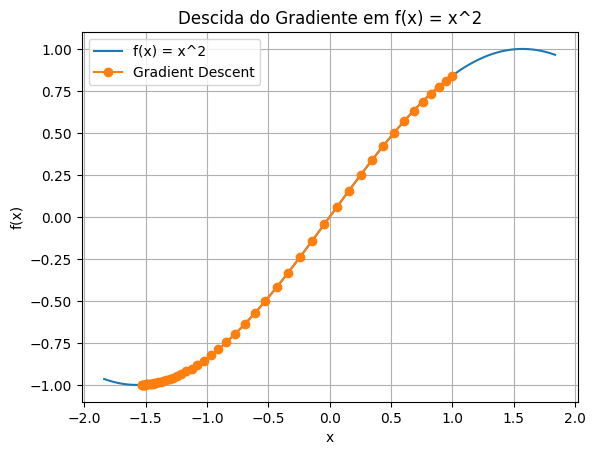

In [60]:
history = gradient_descent(
    gradient_fn,
    initial_val=1,
    learning_rate=0.1,
    n_iter=50)

print("min_x: ", history[-1], "f(min_x): ", objective_fn(history[-1]))
plot2d(history, objective_fn)

### Atividade: $x\ sin(x)$

In [ ]:
import numpy as np

def objective_fn(x):
    return x * np.sin(x)

def gradient_fn(x):
    return ...  # <<< TODO


min_x:  -4.918549787086269 f(min_x):  -4.814394689038597


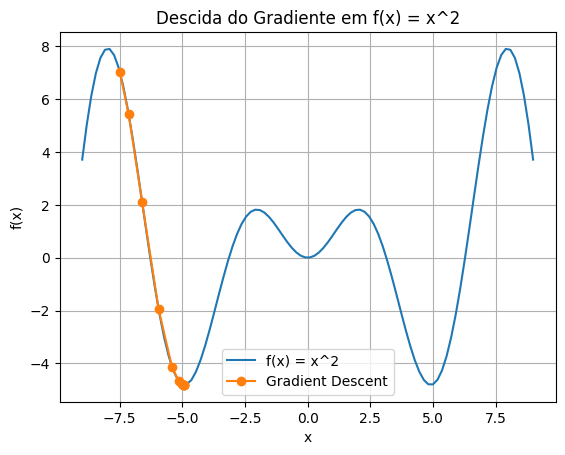

In [62]:
history = gradient_descent(
    gradient_fn,
    initial_val=-7.5,
    learning_rate=0.1,
    n_iter=10)

print("min_x: ", history[-1], "f(min_x): ", objective_fn(history[-1]))
plot2d(history, objective_fn)

### Atividade: $-3x^3 - 5x^2 + 3x - 5$

In [ ]:
import numpy as np

def objective_fn(x):
    return -3 * x ** 3 - 5 * x ** 2 + 3 * x - 5

def gradient_fn(x):
    return ...  # <<< TODO


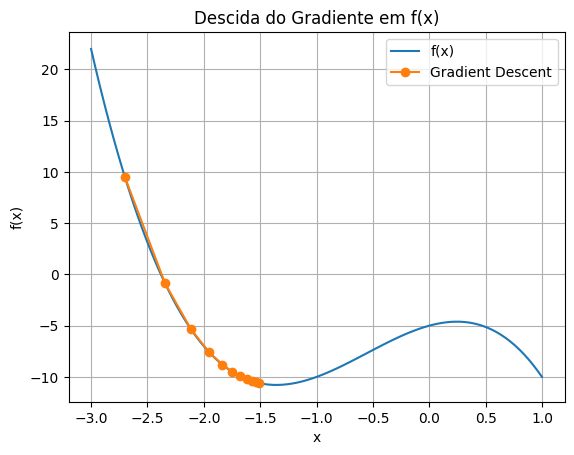

In [ ]:
history = gradient_descent(
    gradient_fn,
    initial_val=-2.7,
    learning_rate=0.01,
    n_iter=10)

print("min_x: ", history[-1], "f(min_x): ", objective_fn(history[-1]))
plot2d(history, objective_fn)

### Atividade: $x^2 + x^2\ cos(x)^2 $

In [ ]:
import numpy as np

def objective_fn(x):
    return x ** 2 + (x ** 2) * (np.cos(x) ** 2)

def gradient_fn(x):
    return ...  # <<< TODO


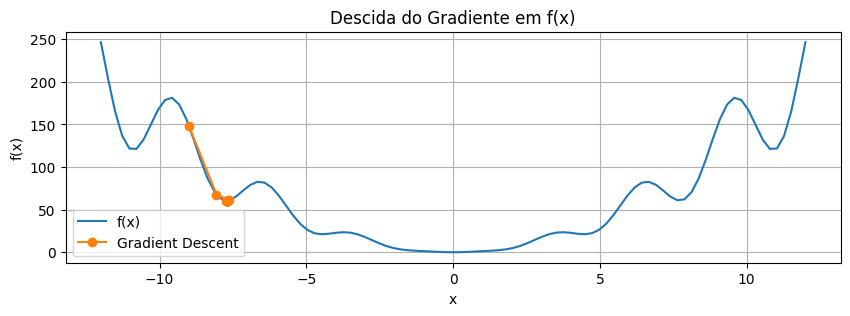

In [ ]:
history = gradient_descent(
    gradient_fn,
    initial_val=-9,
    learning_rate=1e-2,
    n_iter=20)

plt.figure(figsize=(10, 3))
print("min_x: ", history[-1], "f(min_x): ", objective_fn(history[-1]))
plot2d(history, objective_fn)

### Atividade: $x^2 + y^2 + \left( x^2 + y^2 \right) * \left[cos(x)^2 + cos(y)^2 \right]$

In [ ]:
import numpy as np

def objective_fn(w):
    x, y = w
    return (x ** 2 + y ** 2) + (x ** 2 + y ** 2) * (np.cos(x) ** 2 + np.cos(y) ** 2)

def gradient_fn(w):
    x, y = w
    return ...  # <<< TODO


In [ ]:
history = gradient_descent(
    gradient_fn,
    initial_val=np.array([-15, -15]),
    learning_rate=0.005,
    n_iter=20)

history[-1]

array([-10.47556881, -10.47556881])

In [ ]:

# Extract x, y, and z = f(x, y) from history
x_path = [w[0] for w in history]
y_path = [w[1] for w in history]
z_path = [objective_fn(w) for w in history]

# Surface for f(x, y)
X = np.linspace(-20, 20, 100)
Y = np.linspace(-20, 20, 100)
X, Y = np.meshgrid(X, Y)
Z = X ** 2 + Y ** 2 + (X ** 2 + Y ** 2) * (np.cos(X) ** 2 + np.cos(Y) ** 2)

# Create the 3D plot
fig = go.Figure()

# Function surface
fig.add_trace(go.Surface(
    z=Z, x=X, y=Y,
    colorscale='Viridis',
    opacity=0.5,
    showscale=False,
    name='Surface'))

# Descent path
fig.add_trace(go.Scatter3d(
    x=x_path,
    y=y_path,
    z=z_path,
    mode='lines+markers',
    line=dict(color='red', width=4),
    marker=dict(size=4, color='red'),
    name='Gradient Descent Path'
))

# Layout
fig.update_layout(
    title='Gradient Descent Path on f(x, y)',
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='f(x, y)',
        aspectmode='manual',  # Set fixed aspect ratio
        aspectratio=dict(x=1.5, y=1.5, z=0.7)  # Tweak this for better visuals
    ),
    autosize=False,
    width=800,
    height=500,
    margin=dict(l=0, r=0, b=100, t=50)
)

fig.show()